<a href="https://colab.research.google.com/github/yandexdataschool/nlp_course/blob/2025/resources/_under_construction/25/week_extra/vlm_practice_qwen25_omni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: using multimodal LLMs

In this notebook we deploy and play with Qwen/Qwen2.5-Omni-3B or 7B - a decent small-scale model combining text, audio, image and video inputs with text and audio outputs.

This is a decent (for its size), but not the best model available. If you're choosing the best model for your case, consult thematic leaderbords such as:
* [lmarena.ai/leaderboard](https://lmarena.ai/leaderboard)'s vision section for both proprietary and open-source models,
* [Open VLM Leaderboard](https://huggingface.co/spaces/opencompass/open_vlm_leaderboard) for vision+language models specifically,

As of november-december 2025, popular choices would include:

* [Qwen3 omni](https://huggingface.co/collections/Qwen/qwen3-omni) family, a more recent version or [Qwen3-VL](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct) for vision-optimized models;
* [PaliGemma family](https://huggingface.co/collections/google/paligemma-release) for broader multilinguality;
* [Kimi-VL-A3B-Thinking-2506](https://huggingface.co/moonshotai/Kimi-VL-A3B-Thinking-2506) (16B) for vision + reasoning.
* [BAGEL-7B-MoT](https://huggingface.co/ByteDance-Seed/BAGEL-7B-MoT) for image generation with LLMs.

You can also find a tutorial for fine-tuning VLMs in colab: [finetune_paigemma.ipynb](https://colab.research.google.com/github/google-research/big_vision/blob/main/big_vision/configs/proj/paligemma/finetune_paligemma.ipynb)

*[Special thanks to [Asya Fadeeva](https://scholar.google.com/citations?user=SodvsocAAAAJ) and [Denis Kuznedelev](https://scholar.google.com/citations?user=L78B2lcAAAAJn) for their help in preparing this demo]*

In [ ]:
# !pip install accelerate==0.32.1 transformers==4.57.3 bitsandbytes==0.48.2 qwen-omni-utils[decord]==0.0.8
# colab might ask you to restart session after installing this. If it does - please restart it as requested.

In [1]:
%env HF_HUB_DISABLE_XET=1 # Lệnh đặc biệt của Jupyter để thiết lập biến môi trường. Nó vô hiệu hóa backend XetHub của Hugging Face để tránh một số lỗi mạng hoặc tối ưu tốc độ tải mô hình.
import torch
import transformers
from qwen_omni_utils import process_mm_info # để xử lý dữ liệu đa phương tiện (Multi-Modal).
from IPython.display import display, Audio, Image # : Công cụ để hiển thị trực tiếp hình ảnh (Image) và phát âm thanh (Audio) ngay trong giao diện Notebook.
MODEL_NAME = "Qwen/Qwen2.5-Omni-3B"  # or change to -7B with quantization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformers.Qwen2_5OmniForConditionalGeneration.from_pretrained(  # if it can't download in 15min, restart session
    MODEL_NAME, torch_dtype="auto", device_map="auto", low_cpu_mem_usage=True,
    quantization_config=None if MODEL_NAME.endswith("3B") else transformers.BitsAndBytesConfig(load_in_4bit=True)
)
# bnb_config = transformers.BitsAndBytesConfig(load_in_4bit=True)

# model = transformers.Qwen2_5OmniForConditionalGeneration.from_pretrained(
#     MODEL_NAME, 
#     torch_dtype="auto", 
#     device_map="auto", 
#     low_cpu_mem_usage=True,
#     quantization_config=bnb_config  # Đã thay đổi ở đây
# )

processor = transformers.Qwen2_5OmniProcessor.from_pretrained(MODEL_NAME, max_pixels=640 * 480)  # vary max image size to fit into GPU memory
SYSTEM_MESSAGE = {"role": "system", "content": [{"type": "text", "text": "You are Qwen, a virtual human developed by the Qwen Team, Alibaba Group, capable of perceiving auditory and visual inputs, as well as generating text and speech."}],}

# system prompt dùng chat template:
# "role" (Vai trò): Ai đang nói? có nhiều loại roles
# "content" (Nội dung): Người đó nói cái gì?, trong mảng thì có thể chứa nhiều types mối type có template khác nhau nữa
# Trong đoạn code của bạn, "content" không phải là một chuỗi chữ (string) bình thường mà là một danh sách (list):
# "content": [{"type": "text", "text": "..."}]
# Đây là cấu trúc dành riêng cho Mô hình đa phương thức (Multimodal). Vì Qwen2.5-Omni có thể nhìn và nghe, nên phần content phải được thiết kế dạng danh sách để chứa nhiều loại dữ liệu cùng lúc. Ví dụ, một User Prompt đa phương thức sẽ trông như thế này:


env: HF_HUB_DISABLE_XET=1 # Lệnh đặc biệt của Jupyter để thiết lập biến môi trường. Nó vô hiệu hóa backend XetHub của Hugging Face để tránh một số lỗi mạng hoặc tối ưu tốc độ tải mô hình.


`torch_dtype` is deprecated! Use `dtype` instead!


config.json: 0.00B [00:00, ?B/s]

Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/832 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

torch_dtype="auto": Tự động chọn kiểu dữ liệu tối ưu nhất (thường là bfloat16 hoặc float16) để tính toán.

device_map="auto": Tự động chia mô hình vào các phần cứng khả dụng (GPU/CPU/RAM) để tránh tràn bộ nhớ.

quantization_config: Đây là một mẹo tối ưu rất hay trong code. Nếu bạn dùng bản 3B (nhẹ), nó sẽ không nén (None). Nhưng nếu bạn đổi tên mô hình thành bản 7B (nặng hơn), nó sẽ tự động kích hoạt lượng tử hóa 4-bit (load_in_4bit=True) để bóp nhỏ dung lượng mô hình, giúp chạy được trên các GPU có VRAM thấp.

Model AI không hiểu trực tiếp file ảnh hay âm thanh, nó chỉ hiểu các ma trận số (tensor). processor làm nhiệm vụ "dịch" dữ liệu thô thành định dạng AI hiểu được.

max_pixels=640 * 480: Ép độ phân giải hình ảnh đầu vào tối đa là 640x480 để tiết kiệm bộ nhớ card đồ họa (VRAM). Bạn có thể tăng số này nếu có GPU mạnh.







use_audio_in_video=True: Nếu đầu vào của bạn là một đoạn Video (mp4), tham số này báo cho AI biết: "Hãy nghe cả tiếng trong cái video đó nhé, đừng chỉ nhìn hình". Ở trường hợp của bạn không có video nên nó không có tác dụng, nhưng để True mặc định cũng không sao.

thinker_do_sample=False: thinker là bộ phận sinh ra Văn bản (Text) của AI. False (tắt tính năng lấy mẫu) có nghĩa là bắt AI phải chọn từ ngữ có xác suất đúng cao nhất một cách máy móc, logic và an toàn. Điều này giúp câu trả lời bằng chữ không bị "ảo giác" (nói lung tung).

talker_do_sample=True: talker là bộ phận sinh ra Giọng nói (Audio). True (bật tính năng lấy mẫu ngẫu nhiên) giúp giọng nói được tạo ra có độ rung, ngữ điệu, nhấn nhá cảm xúc thay đổi linh hoạt, không bị đều đều vô hồn như robot đọc văn.

--2026-08-07 06:20:39--  https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/dikiy_ogurec.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62362 (61K) [image/jpeg]
Saving to: ‘img.jpg’

img.jpg             100%[===================>]  60.90K  --.-KB/s    in 0.001s  

2026-08-07 06:20:39 (40.5 MB/s) - ‘img.jpg’ saved [62362/62362]



Setting `pad_token_id` to `eos_token_id`:8292 for open-end generation.


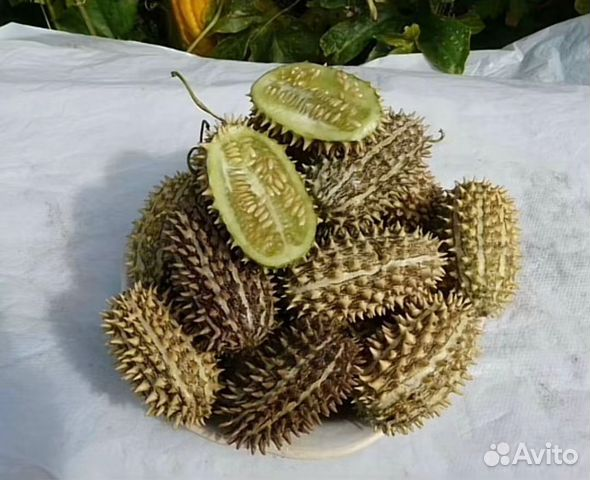

O h ,   t h a t ' s   a   d u r i a n !   I t ' s   a   t r o p i c a l   f r u i t   w i t h   a   r e a l l y   s t r o n g   s m e l l .   T h e   s p i k y   o u t e r   s h e l l   i s   w h a t   y o u   s e e   i n   t h e   p i c t u r e .   I t   h a s   a   u n i q u e   t a s t e   a n d   t e x t u r e .   H a v e   y o u   e v e r   t r i e d   i t ?


In [2]:
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/dikiy_ogurec.jpg -O img.jpg

#Đây chính là cấu trúc hội thoại mà chúng ta đã bàn ở trên. Nó gộp SYSTEM_MESSAGE (quy định tính cách) và tin nhắn của người dùng (user).
conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": "./img.jpg"},  # image will be resized, see max_pixels above
    {"type": "text", "text": "What on Earth is this?"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True) # apply_chat_template: Dịch cấu trúc conversations thành một chuỗi văn bản thuần túy theo chuẩn của Qwen (ví dụ chèn thêm các thẻ như <|im_start|>user...<|im_end|>).
# add_generation_prompt=True: Tự động mồi thêm thẻ <|im_start|>assistant ở cuối chuỗi để AI biết "Đến lượt bạn trả lời rồi đấy".
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
# Khi quét không thấy audio hay video nào trong câu hỏi của bạn, nó sẽ gán các biến audios và videos là None (hoặc rỗng []). Nên thực tế ở đây chỉ có ảnh và text prompt
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device) # padding=True: Khi đưa dữ liệu vào AI, các ma trận phải có độ dài bằng nhau. Tham số này sẽ tự động điền thêm số 0 (hoặc các ký tự độn) vào những chỗ bị thiếu để làm vuông vức ma trận dữ liệu.
from IPython.display import display, Audio, Image
speaker = "Chelsie"  # or "Ethan" for male voice. Specific to Qwen2.5 Omni
text_ids, audio = model.generate(**inputs, speaker=speaker, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True) # note phía trên
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt # Lệnh cắt ma trận [:, inputs['input_ids'].shape[1]:]: Rất quan trọng. PyTorch thường trả về cả câu hỏi của bạn cộng với câu trả lời của AI. Dòng code này cắt bỏ phần câu hỏi đi, chỉ giữ lại phần AI vừa sinh ra.
text, = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False) # processor.batch_decode: Dịch các mã số ID vô nghĩa (ví dụ: [450, 1234, 89]) ngược lại thành chữ tiếng Anh/Việt mà con người đọc được.
display(Image("img.jpg"))
print(*text)  # note: if the model says it's a durian, don't trust it! # Trong Python, dấu * đứng trước một biến được gọi là thuật toán Unpacking (Bóc vỏ). trước đó decode trả về list hay tuple
display(Audio(data=audio.reshape(-1).detach().cpu().numpy(), rate=24000,)) # Tạo một trình phát nhạc nhỏ (Audio player) với tần số lấy mẫu 24000 Hz để bạn có thể bấm "Play" và nghe AI nói câu trả lời.

process_mm_info: Hàm này đọc cấu trúc hội thoại, tìm đường dẫn ảnh/âm thanh và nạp các file đó từ ổ cứng lên bộ nhớ.

processor(...): Bước quan trọng nhất. Nó gộp văn bản (đã mã hóa) và hình ảnh (đã được resize về max_pixels), biến tất cả thành dạng tensor của PyTorch (return_tensors="pt").

.to(model.device): Đẩy toàn bộ khối dữ liệu này lên card đồ họa (GPU) để AI xử lý.

# Audio input and output

In [7]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [8]:
!wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_DL/491c333ae84340677514a06af153d7dd5c55abd7/week10_speech/sample1.wav -O ./sound.wav

conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "text", "text": "Transcribe the spoken phrase in English, Spanish and French."},
    # {"type": "text", "text": "Transcribe the spoken phrase in Vietnamese."}, # model chưa giải quyết tốt audio sinh tiêng VIỆT nên bị kẹt VRAM luôn
    {"type": "audio", "audio": "sound.wav"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)

text_ids, audio = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(Audio("./sound.wav"))
display(Audio(data=audio.reshape(-1).detach().cpu().numpy(), rate=24000,))
print(*text)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Setting `pad_token_id` to `eos_token_id`:8292 for open-end generation.


English: That's no moon. It's a space station. Spanish: Eso no es una luna. Es una estación espacial. French: Ce n'est pas une lune. C'est une station spatiale. If you want to know more about translating other phrases, feel free to ask.


In [9]:
model.disable_talker()  # disable speech module to save GPU time/memory on harder queries
# WARNING: the cells above will not work with talker disabled!

### Multiple images

Well, from what I can see, the first image with the Godzilla statue is definitely larger. It takes up a much bigger portion of the frame. The second image with the gorilla and the woman is smaller in comparison. So, yeah, the first one is larger. What do you think? Do you have any other images you want to compare?


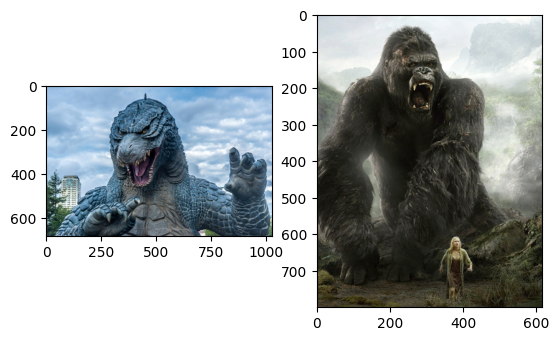

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/godzilla.jpg -O img_A.jpg
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/9c94d8e727fe6494a57e0a8a260a95e193e16287/resources/king-kong-movie.jpg -O img_B.jpg
conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": "./img_A.jpg"},
    {"type": "image", "image": "./img_B.jpg"},
    {"type": "text", "text": "Which one is larger?"}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)
text_ids = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(*text)
plt.subplot(121); plt.imshow(plt.imread("img_A.jpg"))
plt.subplot(122); plt.imshow(plt.imread("img_B.jpg"))

### Playground - upload your own image and prompt

**Note:** The code is currently wired to work on a single image - use the conversation formatting from the examples above to modify it as you see fit. You can also find Qwen2.5 Omni [documentation here](https://huggingface.co/docs/transformers/en/model_doc/qwen2_5_omni).

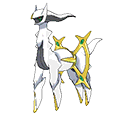

This is a God Pokémon. It's a type of Pokémon that has a very powerful and unique ability. As for its elements, it's a Water - Steel type. Satoshi, the main character in the Pokémon series, does catch this Pokémon. He catches it in the first Pokémon game. So, yeah, it's a pretty cool Pokémon. If you want to know more about it, like its abilities or how to catch it, just let me know.


In [11]:
# from google.colab import files
# user_prompt = "Find the length of the longest side in the triangle."  #<TODO write a prompt string>  # in-class demo: Find the length of the longest side in the triangle.
# uploaded = files.upload("./uploaded/") # Upload your own file
# image_path = next(iter(uploaded.keys()))

# === CHẠY TRÊN KAGGLE ===
user_prompt = "IS THIS A GOD POKEMON? What is it elements? DOES SATOSHI catch this pokemon?"
# Khai báo trực tiếp đường dẫn tới bức ảnh bạn đã upload lên Kaggle
# Ví dụ: Nếu upload vào thư mục hiện tại của Kaggle thì đường dẫn thường là /kaggle/working/tên_ảnh.jpg
image_path = "/kaggle/input/datasets/vishalsubbiah/pokemon-images-and-types/images/arceus.png"  # <--- SỬA TÊN ẢNH CỦA BẠN VÀO ĐÂY

conversations = [SYSTEM_MESSAGE, {"role": "user", "content": [
    {"type": "image", "image": image_path},  # image will be resized, see max_pixels above
    {"type": "text", "text": user_prompt}]}]

text = processor.apply_chat_template(conversations, tokenize=False, add_generation_prompt=True)
audios, images, videos = process_mm_info(conversations, use_audio_in_video=True)
inputs = processor(text=text, audio=audios, images=images, videos=videos, return_tensors="pt",
                   padding=True, use_audio_in_video=True).to(model.device)
text_ids = model.generate(**inputs, use_audio_in_video=True, thinker_do_sample=False, talker_do_sample=True)
text_ids = text_ids[:, inputs['input_ids'].shape[1]:]  # remove prompt
text = processor.batch_decode(text_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
display(Image(image_path, height=320))
print(*text)

Thông tin tri thức ngoài sai 